# Tools use on Random Forest

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.438597,-0.082171,2.346344,1.638998,-2.295027,0
1,-0.499785,-1.189213,-1.225269,1.420271,0.269145,1
2,-1.583687,-1.120221,1.479087,1.019620,-1.207711,0
3,0.698776,1.632713,-1.756055,0.105561,-3.394841,1
4,-0.687028,-0.995415,0.237469,-0.150386,0.338479,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

## For Rows

In [11]:
import random


def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1])))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [12]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [13]:
df1 = sample_rows(df,0.1)

In [14]:
df2 = sample_rows(df,0.1)

In [15]:
df3 = sample_rows(df,0.1)

In [16]:
df1

,col1,col2,col3,col4,col5,target
46,-0.513878,1.113995,-2.582300,3.860095,-0.540016,1
21,0.030736,-0.406800,-2.311841,2.235736,-0.083239,1
20,-2.633982,-2.853870,3.089771,3.194187,-0.568544,0
55,2.403524,-0.614923,-1.124528,0.798739,-2.456470,1
84,-0.378103,-3.190001,-0.977097,-0.500498,0.789529,1
87,-1.445966,-2.299245,-1.603897,2.476220,2.781060,1
47,-2.794539,-0.236616,2.190662,1.915781,-3.514590,0
88,-0.434146,-0.398510,0.334039,1.664919,-2.773759,0
32,0.386571,-0.850406,-1.574396,0.085144,-1.700872,0
12,1.488966,-2.971716,-0.408938,-0.525561,-0.282106,1


In [17]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [28]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

[Text(0.6, 0.8333333333333334, 'x[4] <= -0.554\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.4, 0.5, 'x[0] <= 1.395\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.7, 0.6666666666666667, '  False')]

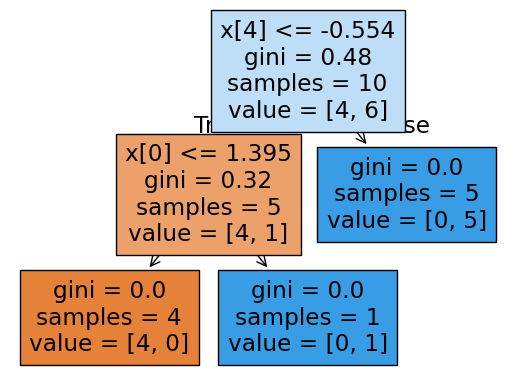

In [30]:
plot_tree(clf1,filled=True)

[Text(0.5, 0.75, 'x[2] <= 0.689\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

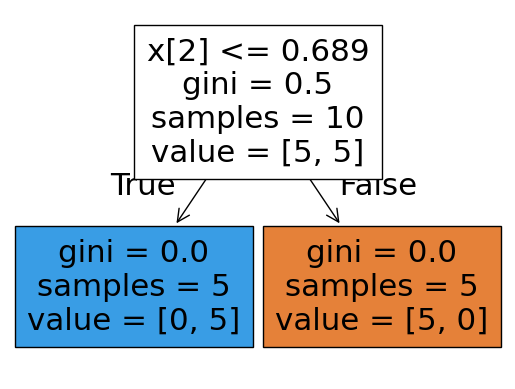

In [31]:
plot_tree(clf2,filled=True)

[Text(0.6, 0.8333333333333334, 'x[2] <= 0.358\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.4, 0.5, 'x[2] <= -1.341\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

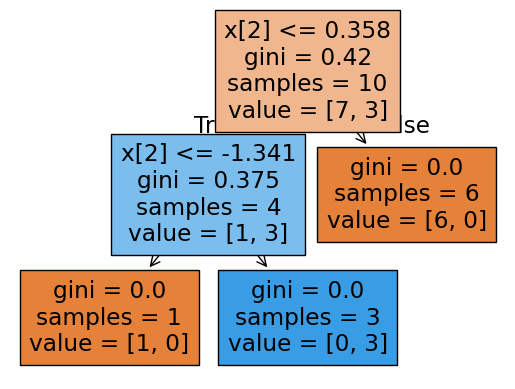

In [32]:
plot_tree(clf3,filled=True)

In [34]:
clf1.predict(
    np.array([
        -0.513878,
        1.113995,
        -2.582300,
        3.860095,
        -0.540016
    ]).reshape(1, -1)
)

/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [35]:
clf2.predict(
    np.array([
        -0.513878,
        1.113995,
        -2.582300,
        3.860095,
        -0.540016
    ]).reshape(1, -1)
)

/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [36]:
clf3.predict(
    np.array([
        -0.513878,
        1.113995,
        -2.582300,
        3.860095,
        -0.540016
    ]).reshape(1, -1)
)

/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [37]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
88,-0.434146,-0.398510,0.334039,1.664919,-2.773759,0
11,-0.252508,0.494103,-1.329137,1.451980,-1.162839,1
64,-0.706970,-0.946138,0.555814,1.456659,-2.122093,0
2,-1.583687,-1.120221,1.479087,1.019620,-1.207711,0
99,-2.876560,0.132163,1.595516,0.282642,-2.746496,0
91,0.947196,-1.390073,-0.068769,1.562053,-0.088492,0
80,-2.360862,-3.266625,2.760979,3.119156,-0.440998,0
47,-2.794539,-0.236616,2.190662,1.915781,-3.514590,0
76,-1.400517,-1.139240,1.031166,0.193704,-0.152171,0
88,-0.434146,-0.398510,0.334039,1.664919,-2.773759,0


## For Columns

In [38]:
import random


def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1])))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [39]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [40]:
df4 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_10351/2163518653.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [41]:
df5 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_10351/2163518653.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [42]:
df6 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_10351/2163518653.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [43]:
print(df4.columns)
print(df5.columns)
print(df6.columns)

Index(['col5', 'col3', 'col1', 'target'], dtype='object')
Index(['col3', 'col2', 'col4', 'target'], dtype='object')
Index(['col4', 'col5', 'col3', 'target'], dtype='object')


In [44]:
df4

,col5,col3,col1,target
21,-0.083239,-2.311841,0.030736,1
7,-1.626834,0.984629,-1.859227,0
85,-1.171625,0.045281,2.378539,1
3,-3.394841,-1.756055,0.698776,1
85,-1.171625,0.045281,2.378539,1
49,0.330430,-2.012291,0.571341,1
92,-2.702167,-1.902489,1.549198,1
74,-0.222562,-2.551875,0.579590,1
15,-1.384483,-0.762032,2.883466,1
12,-0.282106,-0.408938,1.488966,1


In [45]:
from sklearn.tree import DecisionTreeClassifier
clf4 = DecisionTreeClassifier()
clf5 = DecisionTreeClassifier()
clf6 = DecisionTreeClassifier()

In [46]:
clf4.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf5.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf6.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
from sklearn.tree import plot_tree

[Text(0.2857142857142857, 0.9166666666666666, 'x[0] <= -2.04\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.14285714285714285, 0.75, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.21428571428571427, 0.8333333333333333, 'True  '),
 Text(0.42857142857142855, 0.75, 'x[1] <= -1.575\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.3571428571428571, 0.8333333333333333, '  False'),
 Text(0.2857142857142857, 0.5833333333333334, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5714285714285714, 0.5833333333333334, 'x[1] <= -0.733\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.42857142857142855, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7142857142857143, 0.4166666666666667, 'x[0] <= -0.202\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5714285714285714, 0.25, 'x[1] <= 0.358\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.42857142857142855, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7142857142857143, 

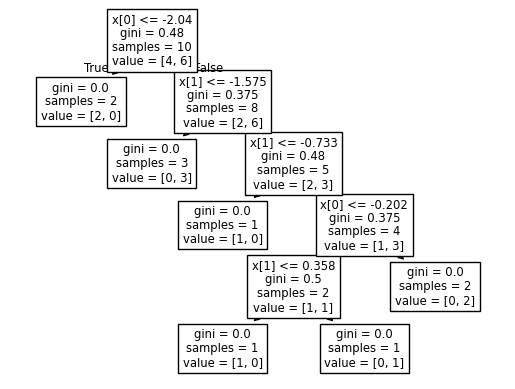

In [48]:
plot_tree(clf4)

[Text(0.5, 0.75, 'x[0] <= -0.039\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.625, 0.5, '  False')]

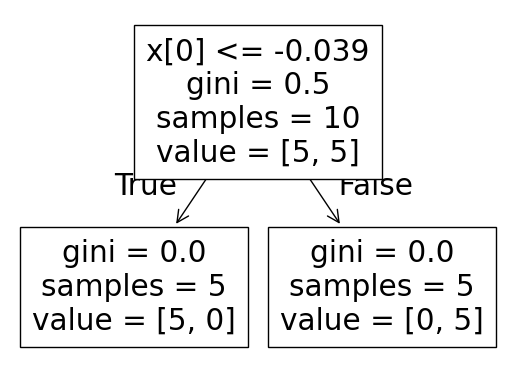

In [49]:
plot_tree(clf5)

[Text(0.3333333333333333, 0.875, 'x[0] <= -0.151\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[0] <= 0.285\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6666666666666666, 0.375, 'x[1] <= -0.132\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

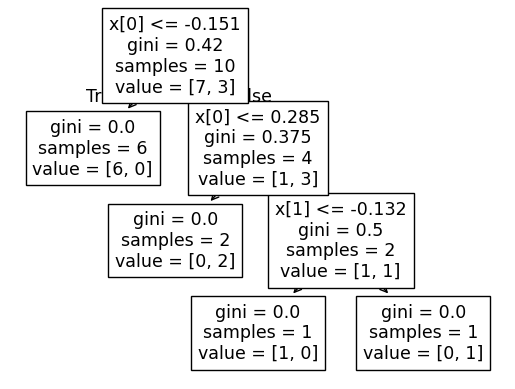

In [50]:
plot_tree(clf6)

In [51]:
clf4.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [52]:
clf5.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [53]:
clf6.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [57]:
df4.sample(14,replace=True)

,col5,col3,col1,target
92,-2.702167,-1.902489,1.549198,1
32,-1.700872,-1.574396,0.386571,0
32,-1.700872,-1.574396,0.386571,0
16,-2.409577,0.931282,-1.895879,0
74,-0.222562,-2.551875,0.579590,1
56,-0.565297,-1.234000,-0.376650,1
49,0.330430,-2.012291,0.571341,1
43,1.019291,-1.285924,-1.461337,1
69,-0.441986,1.212041,-1.373717,0
36,0.074968,-2.380544,0.685836,1


In [58]:
df6.sample(14,replace=True)

,col4,col5,col3,target
14,0.232544,-2.698634,2.159513,0
42,1.622069,0.218785,0.081531,0
20,3.194187,-0.568544,3.089771,0
1,1.420271,0.269145,-1.225269,1
82,-0.036623,-2.491251,0.110051,0
34,1.665555,1.001572,-1.600632,0
42,1.622069,0.218785,0.081531,0
42,1.622069,0.218785,0.081531,0
47,1.915781,-3.514590,2.190662,0
69,0.950413,-0.441986,1.212041,0
